## Goal: Understand the structure, quality, distributions, and relationships in first-party auto claims data in order to identify drivers of subrogation opportunity.

### PHASE 1 — Dataset Integrity & Structure

In [43]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
# Shape & Schema
# Project paths
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
RAW_DATA_PATH = RAW_DATA_DIR / "Training_TriGuard.csv"

df = pd.read_csv(RAW_DATA_PATH)
df.head()

,subrogation,claim_number,year_of_born,gender,email_or_tel_available,safety_rating,annual_income,high_education_ind,address_change_ind,living_status,...,claim_est_payout,vehicle_made_year,vehicle_category,vehicle_price,vehicle_color,vehicle_weight,age_of_DL,accident_type,in_network_bodyshop,vehicle_mileage
0,1.0,6090851,1990.0,F,0.0,75.0,70966.0,1.0,1.0,Rent,...,3218.84,2021.0,Large,16272.12725,red,21620.79697,25.0,multi_vehicle_clear,no,75421.0
1,0.0,4653734,1972.0,F,1.0,94.0,79723.0,1.0,1.0,Rent,...,1338.52,2025.0,Medium,34102.78197,silver,10840.58520,23.0,multi_vehicle_clear,yes,31988.0
2,0.0,1014777,2003.0,F,1.0,76.0,41527.0,1.0,1.0,Own,...,3540.05,2022.0,Compact,15000.00000,silver,24318.12282,23.0,multi_vehicle_unclear,yes,60876.0
3,1.0,8101873,1983.0,F,1.0,54.0,42099.0,1.0,1.0,Rent,...,1507.94,2025.0,Medium,16984.45295,white,36958.26656,23.0,multi_vehicle_unclear,yes,152772.0
4,0.0,5081870,1985.0,F,1.0,54.0,47206.0,1.0,1.0,Own,...,5080.63,2021.0,Compact,46545.72863,blue,11779.17422,17.0,multi_vehicle_clear,yes,41151.0


In [45]:
# Shape & Schema
df.shape

(18001, 29)

In [46]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18001 entries, 0 to 18000
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   subrogation              17999 non-null  float64
 1   claim_number             18001 non-null  int64  
 2   year_of_born             18000 non-null  float64
 3   gender                   18000 non-null  object 
 4   email_or_tel_available   18000 non-null  float64
 5   safety_rating            18000 non-null  float64
 6   annual_income            18000 non-null  float64
 7   high_education_ind       18000 non-null  float64
 8   address_change_ind       18000 non-null  float64
 9   living_status            18000 non-null  object 
 10  zip_code                 18000 non-null  float64
 11  claim_date               18000 non-null  object 
 12  claim_day_of_week        18000 non-null  object 
 13  accident_site            18000 non-null  object 
 14  past_num_of_claims    

### PHASE 2 — Target Variable Understanding (subrogation)

In [47]:
# Target distribution
df["subrogation"].value_counts(normalize=True)

subrogation
0.0    0.771376
1.0    0.228624
Name: proportion, dtype: float64

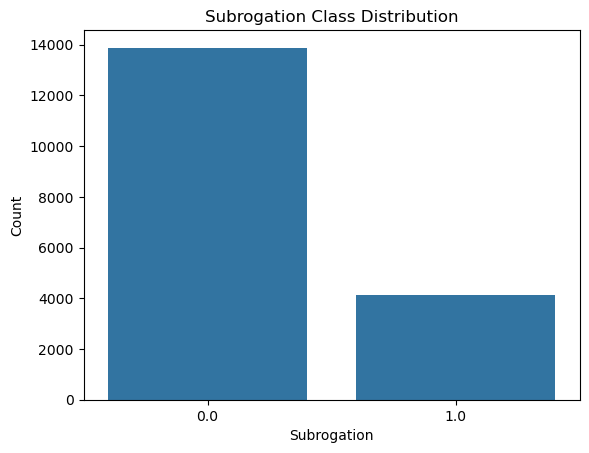

In [48]:
sns.countplot(data=df, x="subrogation")
plt.title("Subrogation Class Distribution")
plt.xlabel("Subrogation")
plt.ylabel("Count")
plt.show()

**Observation:**  
The target variable (`subrogation`) is moderately imbalanced, with ~77% non-subrogated claims and ~23% subrogated claims.  
As a result, accuracy alone would be misleading; evaluation metrics that account for class imbalance (e.g., F1-score, precision/recall) are more appropriate.  
This distribution supports using F1 as a primary metric for the benchmark model.


In [49]:
# Target by time(stability check)
df["claim_date"] = pd.to_datetime(df["claim_date"])
df.groupby(df["claim_date"].dt.to_period("M"))["subrogation"].mean()

claim_date
2015-01    0.230179
2015-02    0.240216
2015-03    0.213152
2015-04    0.243207
2015-05    0.228378
2015-06    0.229677
2015-07    0.209068
2015-08    0.229872
2015-09    0.229371
2015-10    0.217331
2015-11    0.241573
2015-12    0.233154
2016-01    0.239348
2016-02    0.232432
2016-03    0.240838
2016-04    0.206946
2016-05    0.224404
2016-06    0.218056
2016-07    0.216689
2016-08    0.248072
2016-09    0.204082
2016-10    0.219061
2016-11    0.231520
2016-12    0.258412
Freq: M, Name: subrogation, dtype: float64

In [50]:
monthly = df.groupby(
    df["claim_date"].dt.to_period("M")
)["subrogation"].agg(
    total_claims="count",
    subrogated_claims="sum",
    subrogation_rate="mean"
)
monthly

,total_claims,subrogated_claims,subrogation_rate
claim_date,,,
2015-01,782,180.0,0.230179
2015-02,741,178.0,0.240216
2015-03,882,188.0,0.213152
2015-04,736,179.0,0.243207
2015-05,740,169.0,0.228378
2015-06,775,178.0,0.229677
2015-07,794,166.0,0.209068
2015-08,857,197.0,0.229872
2015-09,715,164.0,0.229371


array([<Axes: xlabel='claim_date'>, <Axes: xlabel='claim_date'>],
      dtype=object)

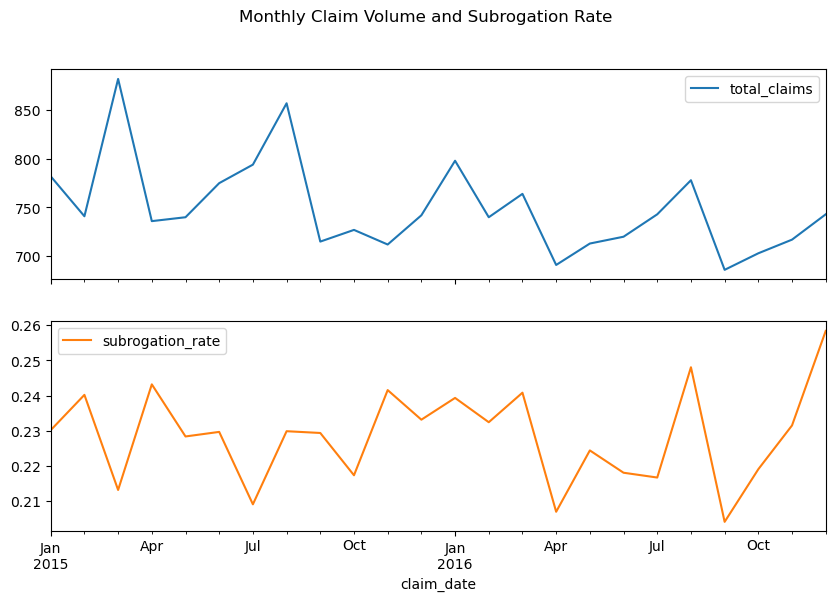

In [51]:
monthly[["total_claims", "subrogation_rate"]].plot(
    subplots=True, figsize=(10,6), title="Monthly Claim Volume and Subrogation Rate"
)

**Observation:**  
Monthly analysis of referred claims from 2015 to 2016 shows that both claim volumes and subrogation outcomes are relatively stable over time. The number of referred claims per month ranges from approximately 680 to 880, while subrogation success rates consistently fall between 20% and 26%. No sharp spikes or drops in either volume or recovery rates are observed, indicating a stable subrogation process without significant temporal disruptions or seasonality. This suggests that subrogation outcomes are primarily driven by claim-level characteristics rather than timing effects, supporting the use of a standard cross-sectional modeling approach.

### PHASE 3 — Data Quality & Sanity Checks

In [52]:
# Missingness analysis
df.isna().sum().sort_values(ascending=False)

subrogation                2
witness_present_ind        1
in_network_bodyshop        1
accident_type              1
age_of_DL                  1
vehicle_weight             1
vehicle_color              1
vehicle_price              1
vehicle_category           1
vehicle_made_year          1
claim_est_payout           1
policy_report_filed_ind    1
channel                    1
liab_prct                  1
past_num_of_claims         1
accident_site              1
claim_day_of_week          1
claim_date                 1
zip_code                   1
living_status              1
address_change_ind         1
high_education_ind         1
annual_income              1
safety_rating              1
email_or_tel_available     1
gender                     1
year_of_born               1
vehicle_mileage            1
claim_number               0
dtype: int64

**Observation:**  
All variables exhibit negligible missingness (<0.1%). The pattern is consistent with random data entry noise rather than informative missingness.  
Simple imputation or row-wise deletion is sufficient, with no expected impact on model performance.


In [53]:
#Duplicate & identifier checks
df["claim_number"].nunique() == len(df)

True

**Observation:**
Claims are unique, no accidental duplication

### PHASE 4 — Numeric Variable Exploration

In [ ]:
# Distribution summary (ALL numeric vars)
continuous_vars = [
    "year_of_born",
    "vehicle_weight",
    "annual_income",
    "vehicle_price",
    "vehicle_mileage",
    "claim_est_payout",
    "age_of_DL",
    "past_num_of_claims",
    "safety_rating",
    "liab_prct"
]

In [74]:
df[continuous_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
year_of_born,18000.0,1980.770500,12.198355,1774.000000,1973.000000,1982.000000,1990.00000,2008.0000
safety_rating,18000.0,74.641833,14.566564,2.000000,65.000000,75.000000,85.00000,100.0000
vehicle_weight,18000.0,22842.168655,11857.504523,2450.138635,14028.319375,20672.207015,29321.49859,101818.9642
annual_income,18000.0,54587.451778,26287.598879,30015.000000,32193.500000,46383.500000,67397.00000,124993.0000
vehicle_price,18000.0,30657.923288,20636.599225,15000.000000,15000.000000,19637.231880,42609.41713,130000.0000
vehicle_mileage,18000.0,80056.858111,30064.396369,500.000000,59587.000000,79765.000000,100325.75000,188839.0000
claim_est_payout,18000.0,3602.507022,3609.644983,65.750000,1321.807500,2414.370000,4519.32750,21504.2800
age_of_DL,18000.0,22.051333,3.359000,16.000000,20.000000,22.000000,24.00000,35.0000
past_num_of_claims,18000.0,3.634611,5.603418,0.000000,0.000000,0.000000,6.00000,43.0000
safety_rating,18000.0,74.641833,14.566564,2.000000,65.000000,75.000000,85.00000,100.0000


## Observation / Conclusion:

The continuous numeric variables show a mix of bounded, monetary, behavioral, and vehicle-related measures with very different scales and distributions. Monetary variables such as `annual_income`, `vehicle_price`, and `claim_est_payout` are strongly right-skewed, with large gaps between the upper quartile and maximum values. This suggests the presence of high-value outliers, which is expected in insurance and financial data but may require transformation before modeling.

`vehicle_weight` and `vehicle_mileage` also show wide ranges and potential high-end outliers. `vehicle_mileage` appears realistic overall, but the spread suggests that vehicle usage intensity could be an important predictor. `past_num_of_claims` is highly zero-inflated, with a median of 0 but a maximum of 43, indicating that most policyholders have no prior claims while a small group has many.

Bounded variables such as `age_of_DL`, `safety_rating`, and `liab_prct` appear more stable and generally well-behaved. However, `year_of_born` has a minimum value of 1774, which is clearly unrealistic and should be investigated or corrected before modeling.

Overall, most numeric variables appear usable, but several require cleaning or transformation. Key issues include right-skewed monetary variables, zero inflation in prior claims, potential outliers in vehicle-related variables, and an unrealistic birth year value.


## Feature engineering suggestions:

- Derive `driver_age_at_claim` from `claim_date` and `year_of_born`, then investigate or cap/remove unrealistic ages caused by invalid birth years.
- Create `driver_license_years` as `driver_age_at_claim - age_of_DL` to estimate how long the driver has been licensed.
- Apply log transformations to strongly right-skewed monetary variables such as `claim_est_payout`, `vehicle_price`, and possibly `annual_income`.
- Create ratio features such as `claim_to_vehicle_value_ratio = claim_est_payout / vehicle_price` to capture claim severity relative to the vehicle’s value.
- Use `age_of_vehicle` directly as the vehicle age measure, and use `vehicle_made_year` mainly for consistency checks or interactions.
- Create vehicle usage features such as `mileage_per_vehicle_year = vehicle_mileage / age_of_vehicle`, handling zero vehicle age carefully.
- Convert `past_num_of_claims` into categorical or binary features, such as `has_prior_claims`, `prior_claims_band`, or `high_prior_claims_flag`.
- Bin bounded numeric variables where useful, such as `safety_rating_band`, `liability_percentage_band`, and `driver_license_age_band`.
- Remove duplicate variables from the analysis list, especially the repeated `safety_rating`.
- Consider scaling numeric variables before models that are sensitive to feature magnitude, such as Logistic Regression, KNN, and SVM.

# Take it from here:

In [56]:
binary_vars = [
    "subrogation",
    "email_or_tel_available",
    "high_education_ind",
    "address_change_ind",
    "policy_report_filed_ind",
    "witness_present_ind",
    "in_network_bodyshop"
]

In [57]:
df[binary_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
subrogation,17999.0,0.228624,0.419958,0.0,0.0,0.0,0.0,1.0
email_or_tel_available,18000.0,0.705833,0.455680,0.0,0.0,1.0,1.0,1.0
high_education_ind,18000.0,0.693444,0.461076,0.0,0.0,1.0,1.0,1.0
address_change_ind,18000.0,0.592056,0.491466,0.0,0.0,1.0,1.0,1.0
policy_report_filed_ind,18000.0,0.604444,0.488983,0.0,0.0,1.0,1.0,1.0


**Binary variable summary:**  
All binary indicators are well-formed (values ∈ {0,1}) with meaningful variation across observations.  
The target variable (`subrogation`) shows moderate imbalance (~23% positive class), while other indicators exhibit reasonable prevalence rates (≈59–71%), suggesting potential predictive value.  
No data quality issues are observed for binary features.


year_of_born
                    mean  median
subrogation                     
0.0          1980.726592  1982.0
1.0          1980.918104  1982.0


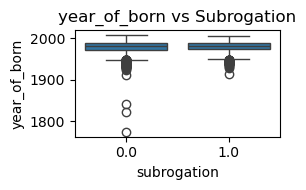


annual_income
                     mean   median
subrogation                       
0.0          54551.114448  46307.5
1.0          54713.773755  46567.0


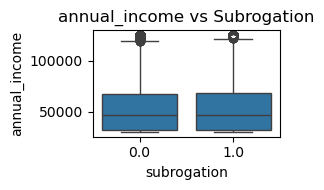


vehicle_price
                     mean       median
subrogation                           
0.0          30549.019772  19484.68427
1.0          31029.168568  20385.09235


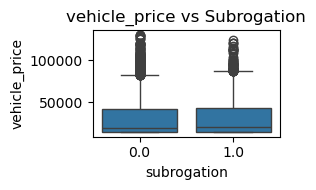


vehicle_mileage
                     mean   median
subrogation                       
0.0          80139.044728  79671.5
1.0          79787.477278  80203.0


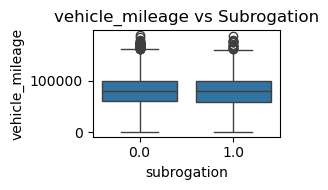


claim_est_payout
                    mean    median
subrogation                       
0.0          3624.194685  2418.805
1.0          3528.943179  2401.590


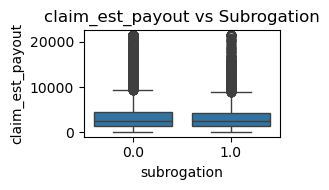


age_of_DL
                  mean  median
subrogation                   
0.0          22.063959    22.0
1.0          22.008748    22.0


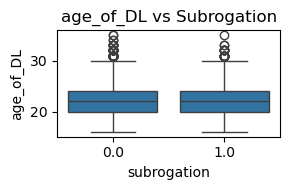


past_num_of_claims
                 mean  median
subrogation                  
0.0          3.585350     0.0
1.0          3.800972     0.0


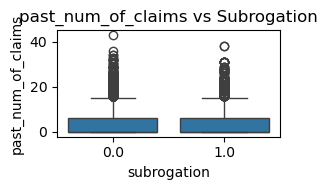


safety_rating
                  mean  median
subrogation                   
0.0          74.599251    75.0
1.0          74.783475    75.0


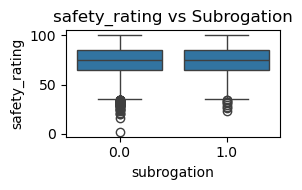


liab_prct
                  mean  median
subrogation                   
0.0          39.889801    40.0
1.0          32.839854    33.0


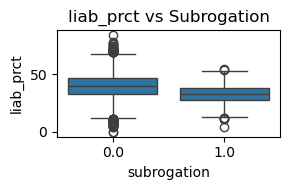

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

for var in continuous_vars:
    print(f"\n{var}")
    stats = (
    df.groupby("subrogation")[var]
      .describe()[["mean", "50%"]]
      .rename(columns={"50%": "median"}))
    print(stats)

    #print(df.groupby("subrogation")[var].describe()[["mean", "median"]])

    plt.figure(figsize=(3, 2))
    sns.boxplot(x="subrogation", y=var, data=df)
    plt.title(f"{var} vs Subrogation")
    plt.tight_layout()
    plt.show()

**Observation:** 

Boxplot comparisons of numeric variables across subrogation outcomes indicate that most continuous features exhibit substantial overlap and minimal distributional shifts, suggesting weak or absent standalone predictive signal. Variables such as annual income, vehicle mileage, estimated claim payout, driver experience, and safety rating show nearly identical medians and interquartile ranges between subrogated and non-subrogated claims. Vehicle price displays a small upward shift for subrogated claims but remains heavily overlapping, indicating a weak and potentially nonlinear relationship. Past number of claims shows differences primarily in the upper tail, consistent with a skewed count distribution where behavioral effects may occur at low values rather than through linear increases. In contrast, liability percentage demonstrates a clear downward shift and reduced overlap for subrogated claims, highlighting it as a strong and theoretically consistent predictor. Overall, these findings suggest that most numeric variables contribute limited linear signal individually, with liability share emerging as the dominant numeric driver and other features likely requiring transformation, binning, or interaction to be useful in modeling.

In [59]:
# Correlation between target and numeric features
df[continuous_vars + ["subrogation"]].corr()["subrogation"].sort_values()

liab_prct            -0.302026
claim_est_payout     -0.011082
age_of_DL            -0.006902
vehicle_mileage      -0.004911
annual_income         0.002599
safety_rating         0.005311
year_of_born          0.006593
vehicle_price         0.009771
past_num_of_claims    0.016160
subrogation           1.000000
Name: subrogation, dtype: float64

**Observation:**

Point-biserial correlations between numeric variables and the subrogation indicator were computed as a complementary diagnostic to boxplot analysis. Liability percentage exhibits a moderate negative correlation with subrogation, confirming it as the strongest linear numeric predictor. All other numeric variables show near-zero correlations, indicating minimal standalone linear association with the target. Variables such as vehicle price and past number of claims display weak correlations consistent with nonlinear or tail-driven effects observed in the boxplots, suggesting that transformation or discretization may be required for effective modeling.

### PHASE 5 — Categorical Variable Exploration

In [60]:
# Selecting categorical variables
categorical_vars = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()
categorical_vars

['gender',
 'living_status',
 'claim_day_of_week',
 'accident_site',
 'witness_present_ind',
 'channel',
 'vehicle_category',
 'vehicle_color',
 'accident_type',
 'in_network_bodyshop']

In [61]:
# Category frequency check
for col in categorical_vars:
    print(f"\n{col}")
    print(df[col].value_counts(normalize=True))


gender
gender
M    0.515167
F    0.484833
Name: proportion, dtype: float64

living_status
living_status
Own     0.548833
Rent    0.451167
Name: proportion, dtype: float64

claim_day_of_week
claim_day_of_week
Monday       0.147611
Saturday     0.146444
Wednesday    0.146056
Sunday       0.141944
Thursday     0.141167
Tuesday      0.139833
Friday       0.136944
Name: proportion, dtype: float64

accident_site
accident_site
Local                   0.263611
Highway/Intersection    0.257611
Unknown                 0.239444
Parking Area            0.239333
Name: proportion, dtype: float64

witness_present_ind
witness_present_ind
N    0.590056
Y    0.409944
Name: proportion, dtype: float64

channel
channel
Broker    0.531833
Phone     0.317667
Online    0.150500
Name: proportion, dtype: float64

vehicle_category
vehicle_category
Large      0.338333
Compact    0.332444
Medium     0.329222
Name: proportion, dtype: float64

vehicle_color
vehicle_color
black     0.150111
white     0.148778
gray  

**Observation:**

Frequency analysis of categorical variables indicates that most features are well balanced, with no categories exhibiting extreme sparsity that would compromise stability. Claim day of week and vehicle category are evenly distributed, while channel and accident type show moderate but acceptable imbalance. Accident site includes a sizable “Unknown” category, suggesting potential data quality or informative missingness. The in-network bodyshop indicator is notably imbalanced and may reflect post-claim processes, warranting caution for predictive modeling. Overall, the categorical variables are suitable for subsequent target-rate analysis.

In [62]:
# Compare subrogation rates across categories and verify stability using raw counts
# (rates show differences; counts ensure they are not driven by small samples)

for col in categorical_vars:
    print(f"\n{col}")

    rate = pd.crosstab(
        df[col],
        df["subrogation"],
        normalize="index"
    )

    count = pd.crosstab(
        df[col],
        df["subrogation"]
    )

    display(rate.round(3))
    display(count)



gender


subrogation,0.0,1.0
gender,,
F,0.750,0.250
M,0.791,0.209


subrogation,0.0,1.0
gender,,
F,6547,2180
M,7337,1935



living_status


subrogation,0.0,1.0
living_status,,
Own,0.785,0.215
Rent,0.755,0.245


...

subrogation,0.0,1.0
accident_type,,
multi_vehicle_clear,0.754,0.246
multi_vehicle_unclear,0.652,0.348
single_car,0.941,0.059


subrogation,0.0,1.0
accident_type,,
multi_vehicle_clear,4659,1521
multi_vehicle_unclear,4270,2284
single_car,4955,310



in_network_bodyshop


subrogation,0.0,1.0
in_network_bodyshop,,
no,0.834,0.166
yes,0.748,0.252


subrogation,0.0,1.0
in_network_bodyshop,,
no,4137,823
yes,9747,3292


**Observation:**

Category-level analysis of subrogation rates reveals that accident context variables are the primary drivers of variation in subrogation outcomes. Accident type shows the strongest differentiation, with single-car accidents exhibiting very low subrogation rates, while multi-vehicle accidents—particularly those with unclear fault—show substantially higher rates. Accident site also displays a clear pattern, with highway and local road incidents associated with higher subrogation compared to parking-area and unknown locations. The presence of a witness is strongly associated with increased subrogation likelihood, consistent with improved liability substantiation. In contrast, demographic and administrative variables such as gender, living status, claim day of week, channel, vehicle category, and vehicle color exhibit only modest or negligible differences in subrogation rates, indicating weak or no standalone predictive signal. Overall, these results highlight accident circumstances rather than claimant or vehicle attributes as the dominant categorical factors related to subrogation.

In [63]:
for col in categorical_vars:
    rate = pd.crosstab(df[col], df["subrogation"], normalize="index")
    spread = rate[1].max() - rate[1].min()
    print(f"{col}: subrogation rate spread = {spread:.2f}")


gender: subrogation rate spread = 0.04
living_status: subrogation rate spread = 0.03
claim_day_of_week: subrogation rate spread = 0.02
accident_site: subrogation rate spread = 0.17
witness_present_ind: subrogation rate spread = 0.15
channel: subrogation rate spread = 0.01
vehicle_category: subrogation rate spread = 0.02
vehicle_color: subrogation rate spread = 0.02
accident_type: subrogation rate spread = 0.29
in_network_bodyshop: subrogation rate spread = 0.09


**Observation:**

Categorical signal strength was summarized using the subrogation-rate spread (max–min subrogation rate across categories). Accident type, accident site, and witness presence showed the largest spreads, indicating strong separation, while channel, vehicle color, vehicle category, and claim day of week showed minimal variation and were treated as weak predictors.

In [64]:
## Chi-Square Test

In [65]:
important_categorical_vars = [
    "accident_type",
    "accident_site",
    "witness_present_ind",
    "gender",          # optional, weak but stable
    "living_status"    # optional, weak but stable
]

In [66]:
from scipy.stats import chi2_contingency

chi2_results = []

for col in important_categorical_vars:
    table = pd.crosstab(df[col], df["subrogation"])
    
    chi2, p, dof, expected = chi2_contingency(table)
    
    chi2_results.append({
        "variable": col,
        "chi2_stat": chi2,
        "p_value": p,
        "degrees_of_freedom": dof
    })

chi2_df = pd.DataFrame(chi2_results).sort_values("p_value")
chi2_df



,variable,chi2_stat,p_value,degrees_of_freedom
0,accident_type,1404.886910,8.564139e-306,2
1,accident_site,689.451543,4.067431e-149,3
2,witness_present_ind,591.162860,1.399493e-130,1
3,gender,42.842313,5.933479e-11,1
4,living_status,23.478805,1.262975e-06,1


**Observation:**

  Chi-square tests of independence confirm strong associations between subrogation and key accident-context variables, including accident type, accident site, and witness presence, with extremely small p-values indicating non-random differences across categories. Demographic variables such as gender and living status are also statistically significant; however, their comparatively smaller chi-square statistics suggest limited practical impact despite large sample sizes. These results corroborate earlier cross-tabulation findings and support prioritizing accident-context features in subsequent modeling.

## PHASE 6 — Binary Indicator Analysis

In [67]:
binary_features = [
    col for col in df.select_dtypes(include="number").columns
    if set(df[col].dropna().unique()) <= {0, 1}
    and col != "subrogation"
]

binary_features

['email_or_tel_available',
 'high_education_ind',
 'address_change_ind',
 'policy_report_filed_ind']

In [68]:
df[binary_features]

,email_or_tel_available,high_education_ind,address_change_ind,policy_report_filed_ind
0,0.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,0.0
...,...,...,...,...
17996,1.0,1.0,1.0,0.0
17997,1.0,0.0,1.0,1.0
17998,1.0,1.0,0.0,0.0
17999,1.0,1.0,1.0,1.0


In [69]:
results = []

for flag in binary_features:
    rates = df.groupby(flag)["subrogation"].mean()
    
    results.append({
        "flag": flag,
        "subrogation_rate_0": rates.get(0, None),
        "subrogation_rate_1": rates.get(1, None),
        "difference_1_minus_0": rates.get(1, 0) - rates.get(0, 0)
    })

phase6_results = pd.DataFrame(results).sort_values(
    "difference_1_minus_0", ascending=False
)

phase6_results


,flag,subrogation_rate_0,subrogation_rate_1,difference_1_minus_0
2,address_change_ind,0.182759,0.260229,0.077470
3,policy_report_filed_ind,0.218008,0.235570,0.017562
0,email_or_tel_available,0.282153,0.206313,-0.075840
1,high_education_ind,0.299021,0.197500,-0.101521


In [70]:
from scipy.stats import chi2_contingency

sig_results = []

for flag in binary_features:
    ct = pd.crosstab(df[flag], df["subrogation"])
    chi2, p, dof, _ = chi2_contingency(ct)
    
    sig_results.append({
        "flag": flag,
        "p_value": p,
        "significant_5pct": p < 0.05
    })

significance_df = pd.DataFrame(sig_results).sort_values("p_value")
significance_df


,flag,p_value,significant_5pct
1,high_education_ind,1.961245e-50,True
2,address_change_ind,6.085753e-34,True
0,email_or_tel_available,3.030425e-28,True
3,policy_report_filed_ind,6.427314e-03,True


**Observation:**

We evaluated binary indicator variables by comparing subrogation rates between absence (0) and presence (1) of each flag. Address change and police report filing were associated with higher subrogation rates, while availability of contact information and higher education levels were associated with lower subrogation rates. Chi-square tests of independence confirm that all binary indicators exhibit statistically significant associations with subrogation at the 5% level. Address change and education level show the strongest effects in both magnitude and statistical evidence, while police report filing displays a weaker but consistent association. These results indicate that the binary indicators provide meaningful univariate signal and are suitable for inclusion in subsequent multivariate modeling.

## PHASE 7 — Temporal Feature Exploration

In [71]:
df["claim_day_of_week"].value_counts()
pd.crosstab(df["claim_day_of_week"], df["subrogation"], normalize="index")

subrogation,0.0,1.0
claim_day_of_week,,
Friday,0.762272,0.237728
Monday,0.762890,0.237110
Saturday,0.782625,0.217375
Sunday,0.762035,0.237965
Thursday,0.781189,0.218811
Tuesday,0.783075,0.216925
Wednesday,0.765601,0.234399


**Observation:**

Subrogation rates vary modestly across claim filing days, ranging from approximately 21.7% to 23.8%. No strong weekday or weekend pattern is observed, suggesting that claim day-of-week exhibits limited standalone predictive power. As a result, this feature is treated as a weak temporal signal and considered primarily as a control or interaction variable in subsequent modeling.

## PHASE 8 — Redundancy & Relationships

<Axes: >

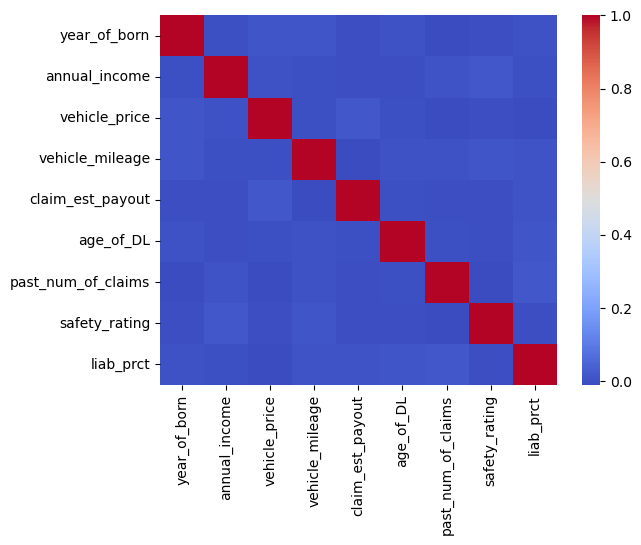

In [72]:
sns.heatmap(df[continuous_vars].corr(), cmap="coolwarm")

**Observatin:**

A correlation scan of continuous variables shows uniformly low pairwise correlations, indicating no evidence of multicollinearity or redundant numeric features. No strong proxy relationships are observed among variables such as income, vehicle price, mileage, or liability percentage. As a result, all continuous variables are retained for modeling, as each appears to contribute independent information.

# Phase 10 — EDA Synthesis (Key Findings)

## 10.1 Target Behavior & Temporal Stability

- Subrogation occurs in approximately **20–26%** of referred claims, indicating moderate class imbalance.
- Monthly analysis of claim volumes and subrogation rates shows **no strong temporal trend or seasonality**.
- Fluctuations in claim volume do **not** correspond to systematic changes in subrogation success.

**Conclusion:**  
The subrogation process appears **stable over time**, suggesting outcomes are driven primarily by claim-level characteristics rather than timing effects.

---

## 10.2 Accident Context as the Primary Driver

- **Accident type** exhibits the strongest variation in subrogation rates:
  - Single-car accidents show very low subrogation likelihood.
  - Multi-vehicle accidents show substantially higher subrogation rates.
- **Accident site** further differentiates outcomes, with highway and local-road accidents outperforming parking-area and unknown locations.
- **Witness presence** is strongly associated with higher subrogation success, consistent with clearer fault attribution.

**Conclusion:**  
Accident-related variables dominate subrogation outcomes and represent the most informative categorical feature group.

---

## 10.3 Binary Indicators (Meaningful but Nuanced)

- Binary indicators show statistically significant associations with subrogation outcomes.
- Directionality varies across indicators:
  - Address change and police report filing are associated with **higher** subrogation rates.
  - Contact availability and higher education levels are associated with **lower** subrogation rates.
- These patterns likely reflect claimant behavior and claim-handling dynamics rather than recoverability alone.

**Conclusion:**  
Binary indicators provide real signal, but effects are heterogeneous and require contextual interpretation.

---

## 10.4 Demographic & Administrative Variables

- Demographic and administrative variables (e.g., gender, living status, channel, vehicle color, claim day of week) show **limited variation** in subrogation rates.
- While some variables are statistically significant due to sample size, effect sizes are small.

**Conclusion:**  
These variables have **weak standalone predictive power** and are secondary contributors.

---

## 10.5 Numeric Variable Insights

- **Liability percentage (`liab_prct`)** shows the clearest numerical separation and aligns directly with subrogation logic.
- Claim payout and vehicle price are right-skewed and show modest positive association with subrogation.
- Past number of claims is zero-inflated with a long right tail.
- Correlation analysis shows **no evidence of strong multicollinearity** among numeric variables.

**Conclusion:**  
Numeric features contribute independent information but require transformation or careful handling.

---

## 10.6 Data Quality & Integrity

- Missingness across numeric variables is negligible.
- `year_of_born` contains implausible values and is not suitable for direct use.
- No duplicate claim identifiers were detected.

**Overall EDA Summary:**  
Subrogation outcomes are primarily driven by **accident context and liability**, with financial exposure providing secondary signal. Demographic and administrative variables play a limited role, and the dataset is of high overall quality.

# Phase 11 — EDA to Modeling & Feature Engineering Decisions

## 11.1 Train/Test Split Strategy

**Decision:** Use a **random train-test split**.

**Justification:**  
EDA shows stable claim volumes and subrogation rates over time, with no evidence of temporal drift or regime change. The data can therefore be treated as cross-sectional.

---

## 11.2 Feature Transformation Decisions

| Feature | EDA Insight | Modeling Decision |
|------|------------|------------------|
| `liab_prct` | Strong, bounded, interpretable | Keep raw |
| `claim_est_payout` | Right-skewed | Log transform |
| `vehicle_price` | Right-skewed | Log transform |
| `past_num_of_claims` | Zero-inflated | Bin or indicator |
| `year_of_born` | Calendar artifact, invalid values | Convert to age |
| `claim_day_of_week` | Weak signal | Retain as low-priority |

---

## 11.3 Categorical Encoding Strategy

- Accident-related categorical variables are prioritized due to strong EDA signal.
- Low-signal categorical variables are retained but deprioritized.
- High-cardinality variables (e.g., ZIP code) are handled cautiously to avoid noise.

---

## 11.4 Feature Selection Philosophy

- No features are dropped solely based on univariate EDA results.
- EDA is used to **prioritize, transform, and contextualize features**, not to prune aggressively.
- Final feature importance is determined empirically through model performance and interpretation.

---

## 11.5 Model Choice & Evaluation Metric

- **Model:** XGBoost, selected for its ability to capture non-linear relationships and interaction effects observed in EDA.
- **Evaluation Metric:** F1 score, appropriate given class imbalance and the importance of balancing precision and recall.

---

## 11.6 Modeling Risks & Caveats

- Strong predictors (e.g., liability percentage, police report filing) may partially reflect post-incident investigation outcomes.
- Model outputs should be interpreted as **decision-support signals**, not causal estimates.

**Final Modeling Rationale:**  
EDA-driven insights ensure that modeling decisions are grounded in both data behavior and insurance domain logic.